In [14]:
# Importación de librerías base para ciencia de datos
import numpy as np  # Operaciones matriciales y cálculo numérico de alta eficiencia
import pandas as pd  # Estructuras de datos (DataFrames) y herramientas de análisis


In [13]:
# Módulo de carga y preparación de datos
df = pd.read_csv(r'meat_consumption.csv')

In [12]:
# Inspección y validación del contenido del DataFrame
df

,LOCATION,SUBJECT,TIME,KG_CAP,THND_TONNE,Tipo de carne,Ubicación
0,ARG,BEEF,1990,55.370,2588.922,Carne bovina,Argentina
1,ARG,BEEF,1991,51.638,2448.667,Carne bovina,Argentina
2,ARG,BEEF,1992,50.789,2441.882,Carne bovina,Argentina
3,ARG,BEEF,1993,51.465,2507.867,Carne bovina,Argentina
4,ARG,BEEF,1994,48.375,2388.224,Carne bovina,Argentina
...,...,...,...,...,...,...,...
6492,ZMB,SHEEP,2022,0.541,12.314,Carne ovina,Zambia
6493,ZMB,SHEEP,2023,0.546,12.808,Carne ovina,Zambia
6494,ZMB,SHEEP,2024,0.552,13.330,Carne ovina,Zambia
6495,ZMB,SHEEP,2025,0.558,13.880,Carne ovina,Zambia


In [15]:
# Cuantificación de valores faltantes por columna
# .isnull() genera una máscara booleana (True para nulos, False para datos válidos)
# .sum() coacciona los booleanos (True=1, False=0) para obtener el total por variable
df.isnull().sum()

LOCATION        0
SUBJECT         0
TIME            0
KG_CAP        324
THND_TONNE      0
dtype: int64

In [16]:
# Aislamiento de registros con inconsistencias (valores faltantes)
# axis=1 evalúa horizontalmente; True si la fila contiene al menos un valor nulo
nulas = df[df.isnull().any(axis=1)]

# Despliegue de métricas de calidad de datos
print(f"\nTotal de filas con algún dato nulo: {len(nulas)}\n")

# Inspección visual de la muestra inicial de registros afectados (primeras 20 filas)
print(nulas.head(20))


Total de filas con algún dato nulo: 324

    LOCATION SUBJECT  TIME  KG_CAP  THND_TONNE
737      CHE    BEEF  1990     NaN     173.000
738      CHE    BEEF  1991     NaN     178.000
739      CHE    BEEF  1992     NaN     176.000
740      CHE    BEEF  1993     NaN     171.000
741      CHE    BEEF  1994     NaN     157.000
742      CHE    BEEF  1995     NaN     156.000
743      CHE    BEEF  1996     NaN     157.000
744      CHE    BEEF  1997     NaN     159.000
745      CHE    BEEF  1998     NaN     158.000
746      CHE    BEEF  1999     NaN     156.472
747      CHE    BEEF  2000     NaN     145.939
748      CHE    BEEF  2001     NaN     145.831
749      CHE    BEEF  2002     NaN     146.587
750      CHE    BEEF  2003     NaN     149.728
751      CHE    BEEF  2004     NaN     149.890
752      CHE    BEEF  2005     NaN     152.274
753      CHE    BEEF  2006     NaN     156.941
754      CHE    BEEF  2007     NaN     155.932
755      CHE    BEEF  2008     NaN     163.372
756      CHE    BE

In [17]:
# Reemplazo de valores nulos en la columna 'KG_CAP'
# Calcula la media específica para cada combinación de 'LOCATION' y 'SUBJECT'
# transform('mean') asegura que el resultado tenga la misma longitud que el DataFrame original
df['KG_CAP'] = df['KG_CAP'].fillna(
    df.groupby(['LOCATION', 'SUBJECT'])['KG_CAP'].transform('mean')
)

In [18]:
# Verificación final de la integridad de los datos post-imputación
# Calcula y despliega la cantidad acumulada de valores nulos remanentes por cada columna
df.isnull().sum()

LOCATION        0
SUBJECT         0
TIME            0
KG_CAP        296
THND_TONNE      0
dtype: int64

In [19]:
# Estrategia de respaldo (fallback) para la imputación de datos faltantes
# Agrupa por tipo de carne ('SUBJECT') para calcular la media global de cada producto
# Reemplaza los nulos remanentes en 'KG_CAP' que no pudieron ser imputados a nivel regional
df['KG_CAP'] = df['KG_CAP'].fillna(
    df.groupby('SUBJECT')['KG_CAP'].transform('mean')
)

In [20]:
# Validación conclusiva del proceso de limpieza en la variable objetivo
# Cuenta y despliega el total absoluto de valores nulos remanentes en la columna 'KG_CAP'
print("\nTotal de NaN final:", df['KG_CAP'].isna().sum())


Total de NaN final: 0


In [21]:
# Generación del resumen estadístico descriptivo del DataFrame
df.describe()

,TIME,KG_CAP,THND_TONNE
count,6497.000000,6497.000000,6497.000000
mean,2008.040634,8.892817,1195.811358
std,10.656594,11.002427,4142.639278
min,1990.000000,0.000000,0.000000
25%,1999.000000,1.062000,53.000000
50%,2008.000000,4.140000,233.692000
75%,2017.000000,12.880000,815.019000
max,2026.000000,66.050000,60167.220000


### MODELOS DE APRENDIZAJE SUPERVISADOS (Regresión Logística - Arbol de decisión)

In [12]:
# Cálculo de la mediana de la variable 'KG_CAP' segmentada por tipo de carne ('SUBJECT')
# Se utiliza el método transform('median') para garantizar que el vector resultante
# preserve la dimensión original del DataFrame y permita la asignación directa
df["mediana_por_carne"] = df.groupby("SUBJECT")["KG_CAP"].transform("median")

# Construcción de la variable objetivo binaria ('Target')
# Se evalúa si el consumo supera o iguala la mediana correspondiente de su categoría;
# la máscara booleana resultante se convierte a tipo entero (1: Alto, 0: Bajo)
df["consumo_alto"] = (df["KG_CAP"] >= df["mediana_por_carne"]).astype(int)

# Validación y auditoría interna del proceso de transformación de datos
# Despliegue de una muestra de control de los primeros 100 registros para verificar la lógica aplicada
print(df[["SUBJECT", "KG_CAP", "mediana_por_carne", "consumo_alto"]].head(100))

    SUBJECT  KG_CAP  mediana_por_carne  consumo_alto
0      BEEF  55.370              6.193             1
1      BEEF  51.638              6.193             1
2      BEEF  50.789              6.193             1
3      BEEF  51.465              6.193             1
4      BEEF  48.375              6.193             1
..      ...     ...                ...           ...
95  POULTRY  34.811             11.760             1
96  POULTRY  33.010             11.760             1
97  POULTRY  32.438             11.760             1
98  POULTRY  33.194             11.760             1
99  POULTRY  37.856             11.760             1

[100 rows x 4 columns]


In [13]:
# Importación de librerías esenciales para el modelado de aprendizaje supervisado
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from IPython.display import display



In [15]:
# Definición del conjunto inicial de variables predictoras independientes (Features).
X_inicial = df[[
    "LOCATION",
    "SUBJECT",
    "TIME"
]]

# Codificación de variables categóricas nominales mediante el método One-Hot Encoding.
X = pd.get_dummies(X_inicial, columns=["LOCATION", "SUBJECT"],dtype=int)

# Asignación de la variable objetivo (Target) previamente estructurada.
y = df["consumo_alto"]

# Despliegue de los metadatos y estructuras resultantes para control de calidad.

print("\nPrimeras filas de X:")
display(X.head())

print("\nPrimeras filas de y:")
display(y.head())


Primeras filas de X:


,TIME,LOCATION_ARG,LOCATION_AUS,LOCATION_BGD,LOCATION_BRA,LOCATION_CAN,LOCATION_CHE,LOCATION_CHL,LOCATION_CHN,LOCATION_COL,...,LOCATION_UKR,LOCATION_URY,LOCATION_USA,LOCATION_VNM,LOCATION_ZAF,LOCATION_ZMB,SUBJECT_BEEF,SUBJECT_PIG,SUBJECT_POULTRY,SUBJECT_SHEEP
0,1990,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,1991,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,1992,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,1993,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,1994,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0



Primeras filas de y:


,consumo_alto
0,1
1,1
2,1
3,1
4,1


In [16]:
# Importación del módulo de validación cruzada para aprendizaje supervisado
from sklearn.model_selection import train_test_split

# Partición del conjunto de datos en subconjuntos disjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,                # Matriz de variables predictoras (Features)
    y,                # Vector de la variable objetivo (Target)
    test_size=0.25,   # Proporción asignada al conjunto de prueba (25% del total)
    random_state=42,  # Semilla pseudoaleatoria para garantizar la reproducibilidad del proceso
    stratify=y,       # Muestreo estratificado para preservar la distribución original de clases en ambos subconjuntos
)
print('-------------------------------- ')
print("Datos para la Regresión Logística")
print('-------------------------------- \n')
# Verificación dimensional del conjunto de entrenamiento y prueba
print("X_train:", X_train.shape) # Despliega el número de registros (filas) y de variables codificadas (columnas) para el subconjunto X_train
print("X_test :", X_test.shape) # Despliega la cardinalidad de registros y atributos (filas y columnas) asignados al subconjunto X_test
print()
# Verificación dimensional del vector de etiquetas de entrenamiento y prueba
print("y_train:", y_train.shape) # Despliega el número de registros asignados al subconjunto de entrenamiento de la variable objetivo (y_train)
print("y_test :", y_test.shape)  # Despliega la cantidad de registros asignados al subconjunto de validación de la variable objetivo (y_test)

-------------------------------- 
Datos para la Regresión Logística
-------------------------------- 

X_train: (4872, 49)
X_test : (1625, 49)

y_train: (4872,)
y_test : (1625,)


### MODELO: Regresión Logística

In [17]:
# Importación de la clase de optimización lineal para clasificación binaria
from sklearn.linear_model import LogisticRegression

# Instanciación del algoritmo de clasificación lineal (Regresión Logística)
# max_iter=1000 incrementa el límite de iteraciones del solver para garantizar la convergencia matemática del gradiente
modelo_logistico = LogisticRegression(max_iter=1000)


# Fase de ajuste y optimización de parámetros del estimador (Entrenamiento)
# El algoritmo calcula los coeficientes óptimos resolviendo la función de costo basada en 'X_train' e 'y_train'
modelo_logistico.fit(X_train, y_train)


# Fase de inferencia y generación de predicciones sobre datos no vistos
# El clasificador entrenado mapea las características de 'X_test' para estimar las etiquetas binarias correspondientes
y_pred_log = modelo_logistico.predict(X_test)


# Extracción de las probabilidades condicionales estimadas por el modelo
# predict_proba devuelve un arreglo con las probabilidades para cada clase (0 y 1)
# [:, 1] filtra y selecciona únicamente la probabilidad de pertenencia a la clase positiva (consumo alto)
y_prob_log = modelo_logistico.predict_proba(X_test)[:, 1]


# Despliega el vector de clasificación binaria (0 o 1) para los primeros 10 registros del conjunto de prueba
print("Primeras predicciones de la regresión logística:\n")
print(y_pred_log[:10])

# Despliega las probabilidades brutas de pertenencia a la clase positiva para el mismo segmento de control
print("\nPrimeras probabilidades estimadas:\n")
print(y_prob_log[:10])

Primeras predicciones de la regresión logística:

[1 0 0 1 1 1 1 1 0 1]

Primeras probabilidades estimadas:

[0.79402362 0.39894912 0.3078344  0.55387265 0.96045515 0.72586972
 0.95397125 0.7128126  0.15655004 0.82037364]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [18]:
# Métrica de rendimiento
# Compara el vector de etiquetas reales ('y_test') contra las estimaciones ('y_pred_log')
# Retorna la proporción de predicciones correctas sobre el total de casos evaluados
accuracy_log = accuracy_score(y_test, y_pred_log)


# Construcción de la matriz de confusión para evaluar el rendimiento del clasificador
# Permite desglosar el conteo exacto de Verdaderos Positivos, Verdaderos Negativos, Falsos Positivos y Falsos Negativos
matriz_log = confusion_matrix(y_test, y_pred_log)


# Transformación de la matriz de confusión estructural a un formato tabular de Pandas
matriz_log_df = pd.DataFrame(
    matriz_log,
    index=["Real: Bajo", "Real: Alto"],
    columns=["Predicho: Bajo", "Predicho: Alto"]
)


# Reporte conclusivo del rendimiento del clasificador lineal
print('------------------------------------')
print("Resultados de la Regresión Logística")
print('------------------------------------\n')
print("Accuracy:", round(accuracy_log, 4))  # Despliega la precisión global
print("\nMatriz de confusión:")
display(matriz_log_df)                      # Presentación de matriz (errores Tipo I y Tipo II)

------------------------------------
Resultados de la Regresión Logística
------------------------------------

Accuracy: 0.7735

Matriz de confusión:


,Predicho: Bajo,Predicho: Alto
Real: Bajo,647,165
Real: Alto,203,610


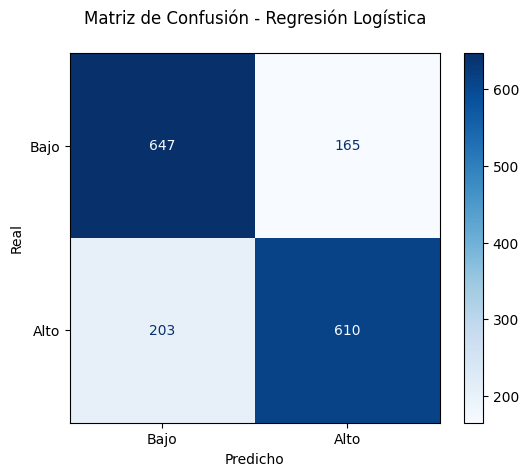

In [19]:
# Importación de librerías scikit-learn y matplotlib
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Instanciación del objeto gráfico de la matriz.
grafico_matriz = ConfusionMatrixDisplay(
    confusion_matrix=matriz_log,      # Mapea los valores numéricos calculados ('matriz_log')
    display_labels=["Bajo", "Alto"]   # asigna etiquetas a los ejes
)

# Configuración y despliegue de Gráfico
grafico_matriz.plot(cmap=plt.cm.Blues)      # Se aplica la paleta cromática secuencial 'Blues' para codificar visualmente la densidad de frecuencias
plt.title("Matriz de Confusión - Regresión Logística\n")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.show()
print()

### MODELO: Árbol de Decisión

In [20]:
# Importación del módulo de división de datos para aprendizaje supervisado
# train_test_split permite fragmentar matrices o DataFrames en subconjuntos disjuntos para entrenamiento y validación
from sklearn.model_selection import train_test_split

# Extracción de variables independientes predictoras (matriz de diseño inicial)
X_inicial = df[["LOCATION", "SUBJECT", "TIME"]]

# Aplicación de One-Hot Encoding
X = pd.get_dummies(X_inicial, columns=["LOCATION", "SUBJECT"])

# Asignación del vector de etiquetas binarias que representa la variable objetivo
y = df["consumo_alto"]

# Partición del conjunto de datos en subconjuntos disjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,                # Matriz de variables independientes codificadas
    y,                # Vector que contiene la variable objetivo binaria
    test_size=0.25,   # Proporción del conjunto total destinada a la validación externa (25%)
    random_state=42,  # Configuración de la semilla pseudoaleatoria para reproducibilidad del experimento
    stratify=y,       # Muestreo estratificado para conservar la distribución de clases en ambos subconjuntos
)

# Verificación de consistencia dimensional en los conjuntos disjuntos
print('--------------------------------')
print("Datos para el Árbol de Decisión")
print('--------------------------------\n')
print("X_train (Entrenamiento):", X_train.shape)
print("X_test (Prueba):", X_test.shape)
print()

--------------------------------
Datos para el Árbol de Decisión
--------------------------------

X_train (Entrenamiento): (4872, 49)
X_test (Prueba): (1625, 49)



In [21]:
# Importación de librerias para Árbol de decisión
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd
from IPython.display import display

# Instanciación del algoritmo de clasificación basado en árboles de decisión
modelo_arbol_optimizado = DecisionTreeClassifier(
    max_depth=15,           # limita la profundidad máxima del árbol para mitigar el sobreajuste (overfitting)
    min_samples_split=10,   # establece el número mínimo de muestras requeridas para segmentar un nodo interno
    random_state=42         # fija la semilla pseudoaleatoria para asegurar la reproducibilidad en la selección de divisiones
)

# Ajuste y optimización del modelo basado en árboles (Entrenamiento)
modelo_arbol_optimizado.fit(X_train, y_train)

# Inferencia y generación de etiquetas predictivas (Predicción)
y_pred_optimizado = modelo_arbol_optimizado.predict(X_test)


# Evaluación analítica y auditoría de los nuevos resultados predictivos
accuracy_opt = accuracy_score(y_test, y_pred_optimizado)
matriz_opt = confusion_matrix(y_test, y_pred_optimizado)

matriz_opt_df = pd.DataFrame(
    matriz_opt,
    index=["Real: Bajo", "Real: Alto"],
    columns=["Predicho: Bajo", "Predicho: Alto"]
)

# Despliegue del reporte estadístico de rendimiento
print('--------------------------------------------')
print("Resultados del Árbol de Decisión OPTIMIZADO")
print('--------------------------------------------\n')
print("Accuracy:", round(accuracy_opt, 4))
print("\nMatriz de confusión mejorada:\n")
display(matriz_opt_df)

--------------------------------------------
Resultados del Árbol de Decisión OPTIMIZADO
--------------------------------------------

Accuracy: 0.7151

Matriz de confusión mejorada:



,Predicho: Bajo,Predicho: Alto
Real: Bajo,355,457
Real: Alto,6,807


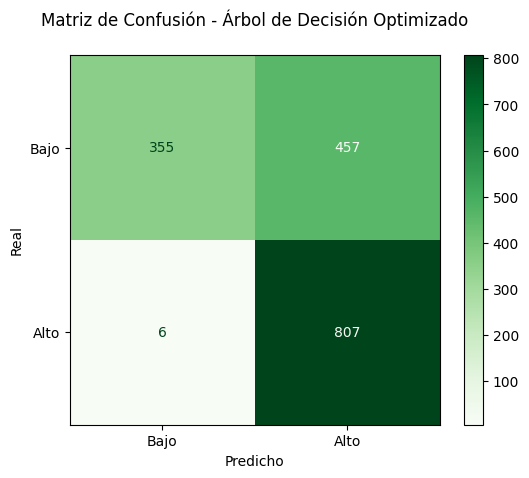

In [22]:
# Importación de librerías scikit-learn y matplotlib
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Instanciación el objeto gráfico de la matriz.
grafico_arbol = ConfusionMatrixDisplay(
    confusion_matrix=matriz_opt,     # asigna la matriz numérica calculada ('matriz_opt')
    display_labels=["Bajo", "Alto"]  # define las etiquetas para los ejes
)

# Generamos y Desplegamos el gráfico
grafico_arbol.plot(cmap=plt.cm.Greens)
plt.title("Matriz de Confusión - Árbol de Decisión Optimizado\n")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.show()

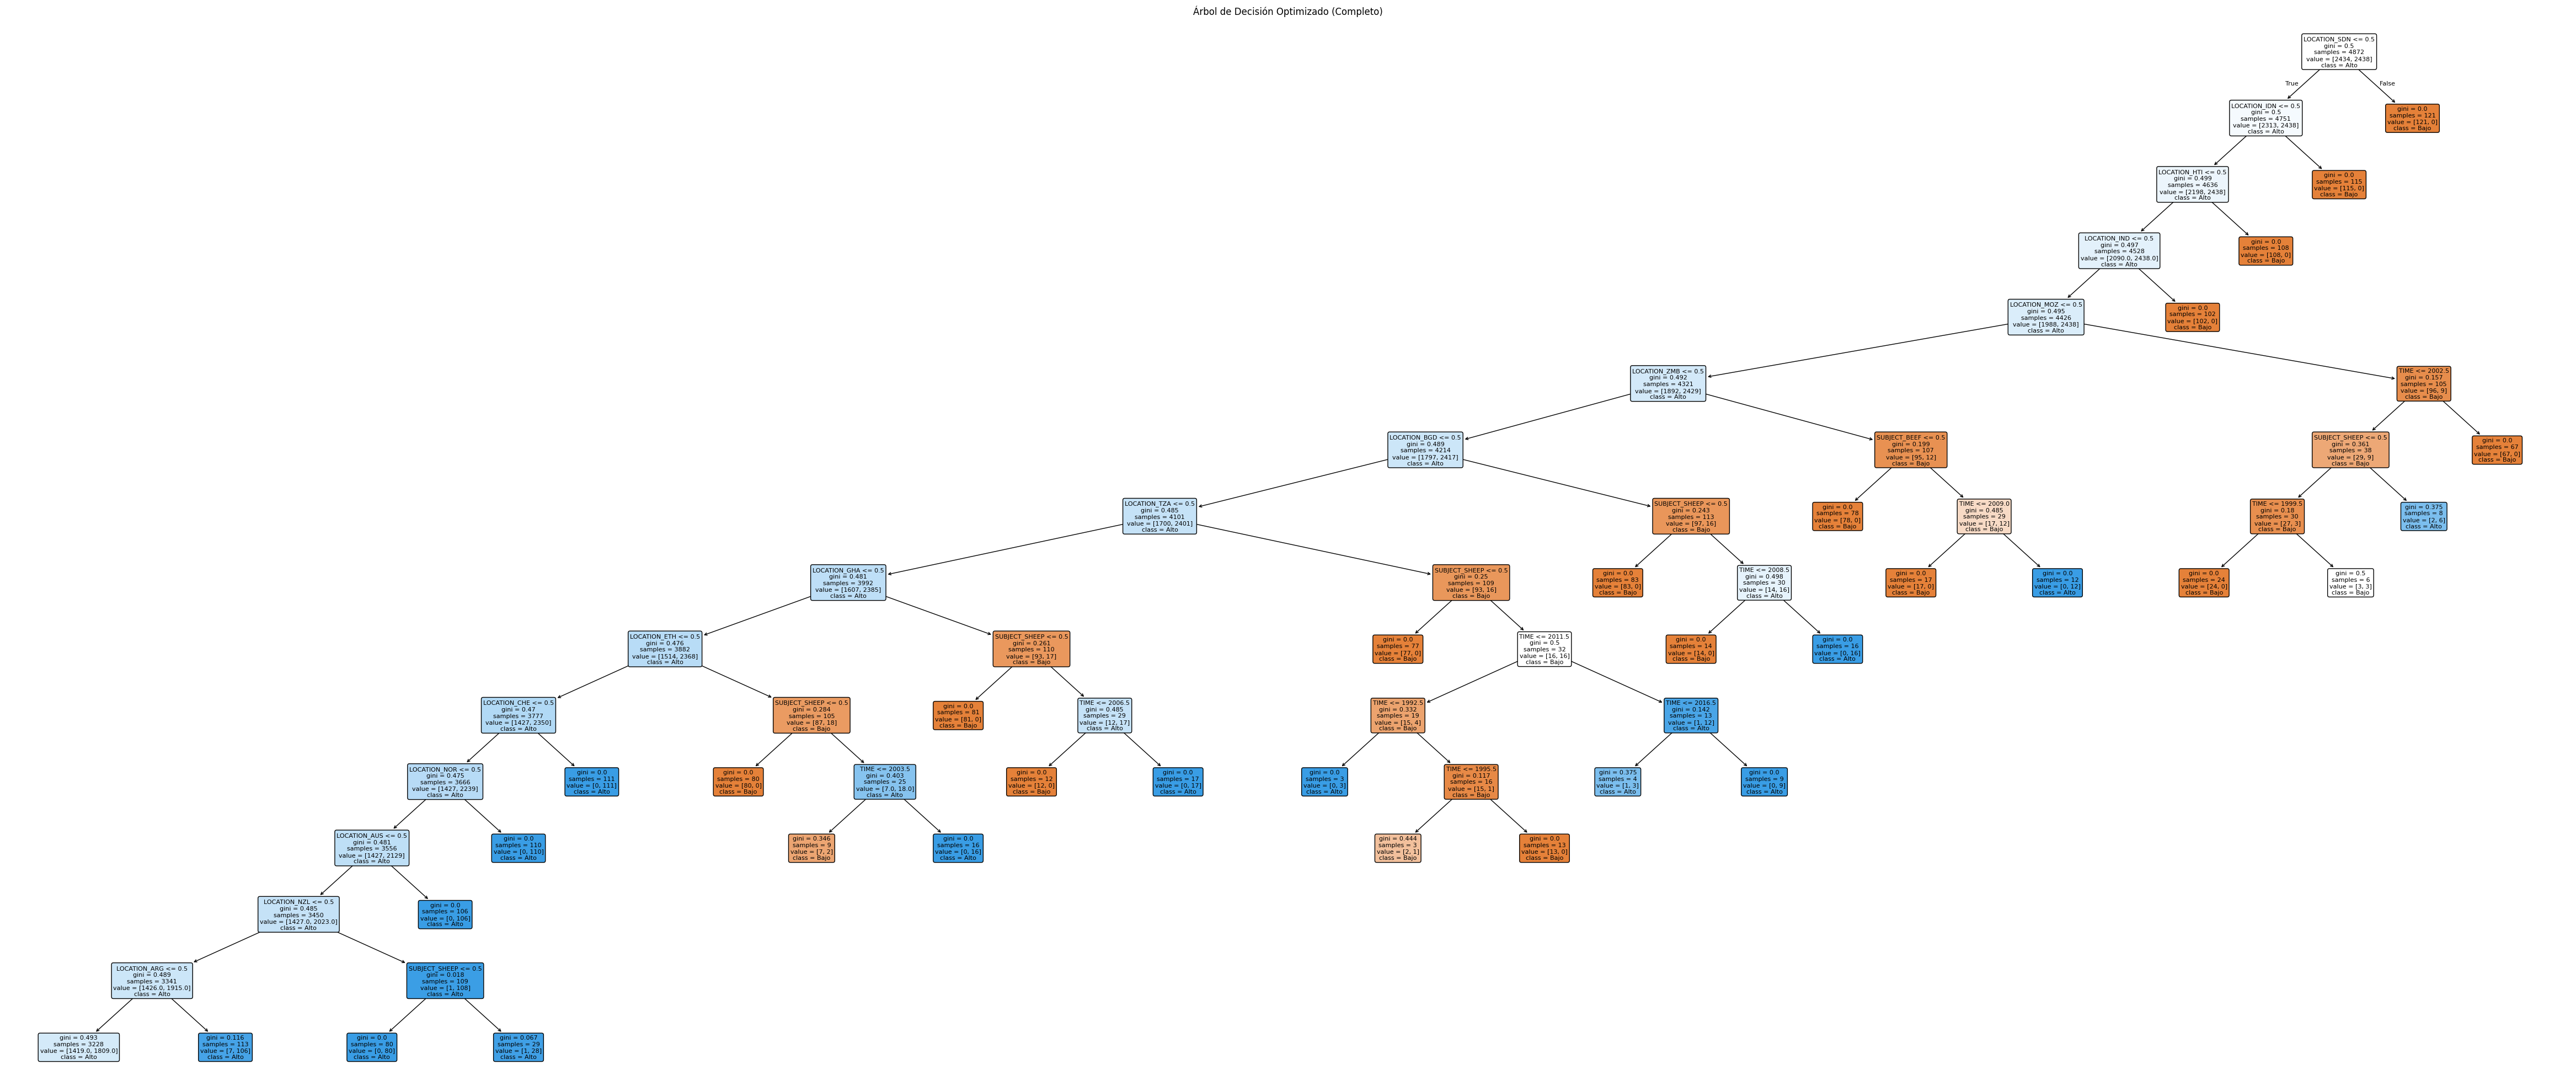

In [23]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Configuración y despliegue del gráfico
plt.figure(figsize=(60, 25))
plot_tree(                    # Generación del diagrama estructural y jerárquico del modelo predictivo
    modelo_arbol_optimizado,
    feature_names=X.columns,          # Asigna los nombres de las columnas codificadas para identificar las reglas de división
    class_names=["Bajo", "Alto"],     # Define las etiquetas categóricas de salida para los nodos terminales
    filled=True,                      # Colorea los nodos según la clase mayoritaria y la pureza
    rounded=True,                     # Aplica bordes redondeado
    fontsize=8                        # Tamaño del texto
)
plt.title("Árbol de Decisión Optimizado (Completo)")
plt.savefig("arbol_completo_carnes.png", format="png", bbox_inches='tight', dpi=300) # Exportación y almacenamiento del diagrama jerárquico del árbol en el almacenamiento local
plt.show()


### GRAFICA COMPARATIVA: Entre modelos Supervisados

,Modelo,Accuracy
0,Regresión Logística,0.7735
1,Árbol de Decisión,0.7151


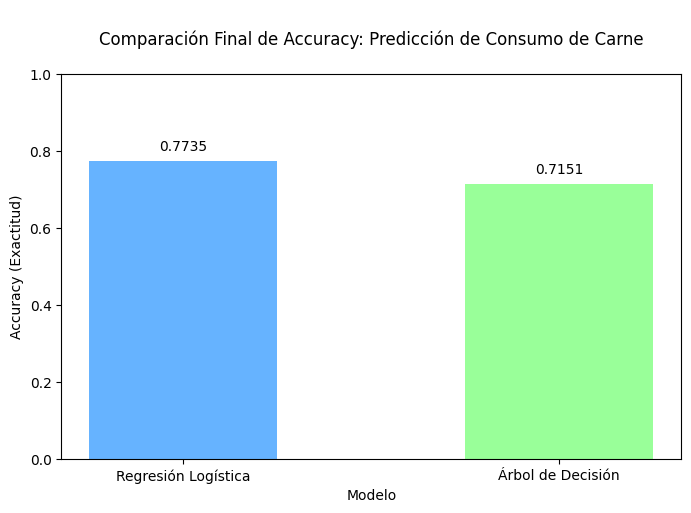

In [24]:
# Importación libreria pandas y matplolib
import pandas as pd
import matplotlib.pyplot as plt

# Construcción del DataFrame consolidado para los modelos finales del experimento
comparacion = pd.DataFrame({
    "Modelo": ["Regresión Logística", "Árbol de Decisión"],
    "Accuracy": [accuracy_log, accuracy_opt]
})

# Aplicación de redondeo a cuatro decimales
comparacion = comparacion.round(4)

# Renderizado de la tabla resumen
display(comparacion)
print()

# Configuración y Despliegue del gráfico
plt.figure(figsize=(8, 5))
colores = ['#66b3ff', '#99ff99']
barras = plt.bar(comparacion["Modelo"], comparacion["Accuracy"], color=colores, width=0.5)
# Configuración de los metadatos y etiquetas del sistema de coordenadas
plt.title("\nComparación Final de Accuracy: Predicción de Consumo de Carne\n")
plt.ylabel("Accuracy (Exactitud)")
plt.xlabel("Modelo")

plt.ylim(0, 1)  # Restricción del rango dinámico del eje

#Etiquetas de datos sobre las barras
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 0.02, round(yval, 4), ha='center', va='bottom')

plt.show()
plt.show()

### MODELO DE APRENDIZAJE NO SUPERVISADO

In [25]:
# Importación de librerías base para la gestión de datos y visualización gráfica
import pandas as pd
import matplotlib.pyplot as plt

# LIBRERÍAS PARA MODELADO DE APRENDIZAJE NO SUPERVISADO Y REDUCCIÓN DE DIMENSIONES
from sklearn.cluster import KMeans                 # Algoritmo de particionamiento basado en centroides
from sklearn.decomposition import PCA              # Reducción lineal de dimensionalidad y extracción de características
from sklearn.metrics import silhouette_score       # Métrica de validación interna para la calidad de los clusters
from sklearn.preprocessing import StandardScaler   # Normalización estadística de variables continuas (Z-score)

Preparación de datos para el modelo

In [26]:
# Transformación de la matriz de datos mediante una tabla dinámica (Pivot Table)
df_perfiles = df.pivot_table(
    index='LOCATION',         # Define la unidad de análisis observacional a nivel regional ('LOCATION')
    columns='SUBJECT',        # Transpone las categorías conceptuales de producto ('SUBJECT') a variables independientes
    values='KG_CAP',          # Centraliza la métrica numérica del consumo per cápita ('KG_CAP')
    aggfunc='mean'            # Aplica el operador de agregación estadística (media aritmética) interanual
).fillna(0)                   # Aplica una política de imputación determinista de valor cero para mitigar la dispersión estructural

# Validación intermedia de la nueva topología matricial del conjunto de datos
print("\nMuestra Dataset para el modelo No Supervisado:\n")
display(df_perfiles.head())



Muestra Dataset para el modelo No Supervisado:



SUBJECT,BEEF,PIG,POULTRY,SHEEP
LOCATION,,,,
ARG,42.954946,6.553811,27.804784,1.365111
AUS,23.777778,18.396139,35.258297,11.901973
BGD,0.894378,0.000000,1.050378,1.048865
BRA,24.409703,10.016270,31.300973,0.439703
CAN,20.855378,18.786622,31.960378,0.864865


###Escalamiento de datos

In [27]:
# Inicialización del operador de estandarización estadística (Z-score Scaling).
scaler = StandardScaler()

# Ajuste del transformador y normalización de la matriz de características continuas
X_escalado = scaler.fit_transform(df_perfiles)

# Control dimensional de la matriz de diseño optimizada para la optimización geométrica
print("\nDimensiones de matriz escalada para el modelo:", X_escalado.shape)
print()


Dimensiones de matriz escalada para el modelo: (44, 4)



In [28]:
from sklearn.cluster import KMeans

# Instanciación del algoritmo de particionamiento no supervisado (K-Means)
kmeans = KMeans (
    n_clusters=5,        # define la partición del espacio muestral en cinco centroides disjuntos
    random_state=42,     # parametriza la semilla pseudoaleatoria para mitigar la variabilidad en la inicialización
    n_init=10            # ejecuta el algoritmo de forma independiente con diferentes semillas para converger en el óptimo global
)

# Ajuste del estimador geométrico y asignación simultánea de etiquetas de clúster
clusters = kmeans.fit_predict(X_escalado)

# Clonación del Dataframe perfiles
df_resultado = df_perfiles.copy()

# Inyección de la variable categórica generada por el modelo
df_resultado['cluster'] = clusters

# Despliegue del reporte inicial de segmentación geopolítica
print("Muestra de Dataframe de Países con su respectivo clúster asignado:\n")
display(df_resultado.head(10))

Muestra de Dataframe de Países con su respectivo clúster asignado:



SUBJECT,BEEF,PIG,POULTRY,SHEEP,cluster
LOCATION,,,,,
ARG,42.954946,6.553811,27.804784,1.365111,4
AUS,23.777778,18.396139,35.258297,11.901973,1
BGD,0.894378,0.000000,1.050378,1.048865,0
BRA,24.409703,10.016270,31.300973,0.439703,4
CAN,20.855378,18.786622,31.960378,0.864865,4
CHE,10.171038,7.655594,15.475712,2.268188,2
CHL,16.043784,15.090216,27.071595,0.587568,4
CHN,3.171730,26.895703,9.842056,2.400486,3
COL,12.164324,3.544189,19.662892,0.253568,2


### Modelo aplicando Análisis de Componentes Principales (PCA)

In [29]:
from sklearn.decomposition import PCA
import pandas as pd
from IPython.display import display

# Inicialización del algoritmo de Análisis de Componentes Principales (PCA)
pca = PCA(n_components=2)   #n_components=2 parametriza la proyección del espacio multidimensional original (4 variables)

# Retorna las coordenadas de las observaciones proyectadas sobre los dos primeros ejes principales (PC1 y PC2)
X_pca = pca.fit_transform(X_escalado)

# Se preserva la alineación geopolítica original mapeando explícitamente el índice de los perfiles regionales
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], index=df_perfiles.index)

# Integración de coordenadas multidimensionales reducidas al conjunto de control
df_resultado['PC1'] = df_pca['PC1']
df_resultado['PC2'] = df_pca['PC2']

# Validación de la topología de la matriz y auditoría interna de registros segmentados
print("Análisis de Componentes Principales por país:\n")
display(df_resultado[['PC1', 'PC2', 'cluster']].head())

Análisis de Componentes Principales por país:



SUBJECT,PC1,PC2,cluster
LOCATION,,,
ARG,2.249078,-0.200631,4
AUS,3.328524,1.728594,1
BGD,-1.732089,0.277665,0
BRA,1.422759,-0.702448,4
CAN,1.804059,-1.230010,4


In [30]:
# Extracción de la proporción de varianza explicada por cada eje
varianza = pca.explained_variance_ratio_

# Evalúa la cantidad agregada de información retenida al proyectar los datos sobre PC1 y PC2
varianza_total = varianza.sum()

# Despliegue de métricas de calidad de la reducción dimensional
print('---------------------------------------')
print("    ANÁLISIS DE VARIANZA EXPLICADA    ")
print('---------------------------------------\n')
print('PC1 (Eje X) resume aproximadamente', round(varianza[0] * 100, 2), '% de la información original.')
print('PC2 (Eje Y) resume aproximadamente', round(varianza[1] * 100, 2), '% de la información original.')
print()
print('-' * 40)
print('Total Retenido (PC1 + PC2):', round(varianza_total * 100, 2), '%')
print('-' * 40)

---------------------------------------
    ANÁLISIS DE VARIANZA EXPLICADA    
---------------------------------------

PC1 (Eje X) resume aproximadamente 49.19 % de la información original.
PC2 (Eje Y) resume aproximadamente 23.94 % de la información original.

----------------------------------------
Total Retenido (PC1 + PC2): 73.13 %
----------------------------------------


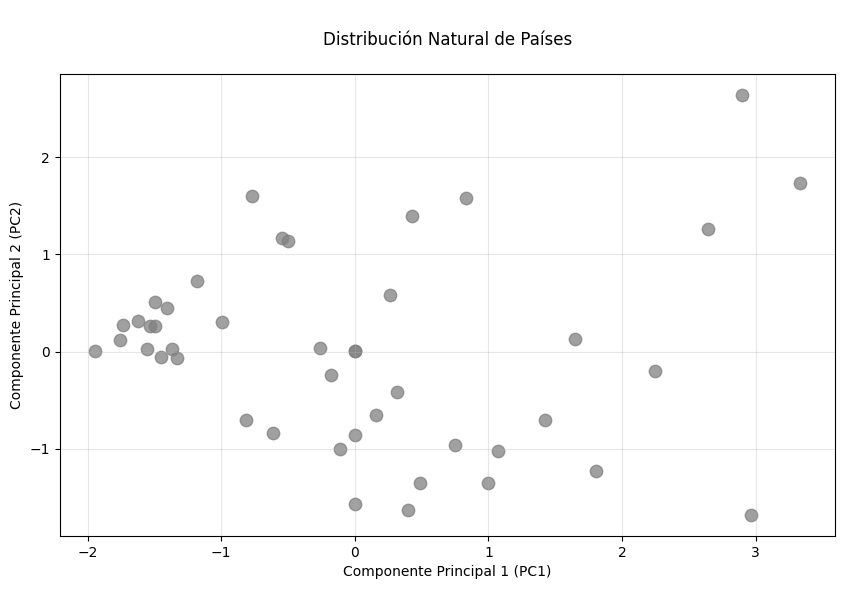

In [31]:
import matplotlib.pyplot as plt

# Definición del lienzo de visualización
plt.figure(figsize=(10, 6))

# Mapeo espacial de las observaciones sobre el plano
plt.scatter(
    df_resultado['PC1'],
    df_resultado['PC2'],
    alpha=0.75,               # Opacidad para facilitar la identificación de agrupaciones naturales densas
    s=80,                     # Diámetro geométrico de los marcadores para un balance visual óptimo
    color='gray'
)

# Configuración de los metadatos y etiquetas de los ejes coordenados del subespacio latente
plt.title('\nDistribución Natural de Países\n')
plt.xlabel('Componente Principal 1 (PC1)')
plt.ylabel('Componente Principal 2 (PC2)')
plt.grid(True, alpha=0.3)
plt.show()

In [32]:
from sklearn.cluster import KMeans

# Inicialización del algoritmo de agrupamiento particional (K-Means)
kmeans = KMeans(
    n_clusters=5,     # parametriza el modelo para identificar cinco estructuras grupales disjuntas
    random_state=42,  # fija la semilla pseudoaleatoria para asegurar la reproducibilidad
    n_init=10         # ejecuta diez iteraciones independientes
)

# El método fit_predict minimiza de forma iterativa la inercia interna del modelo
clusters = kmeans.fit_predict(X_escalado)

# Consolida las categorías cualitativas en la matriz original de 44 observaciones regionales
df_resultado['cluster'] = clusters

# Permite realizar el mapeo de color según el clúster asignado sobre los ejes continuos PC1 y PC2
df_pca['cluster'] = clusters

# Validación estructural y control de calidad de la matriz unificada resultante
print("       Tabla Actualizada \nAnálisis de Componentes Principales por país:\n")
display(df_resultado[['PC1', 'PC2', 'cluster']].head())

       Tabla Actualizada 
Análisis de Componentes Principales por país:



SUBJECT,PC1,PC2,cluster
LOCATION,,,
ARG,2.249078,-0.200631,4
AUS,3.328524,1.728594,1
BGD,-1.732089,0.277665,0
BRA,1.422759,-0.702448,4
CAN,1.804059,-1.230010,4


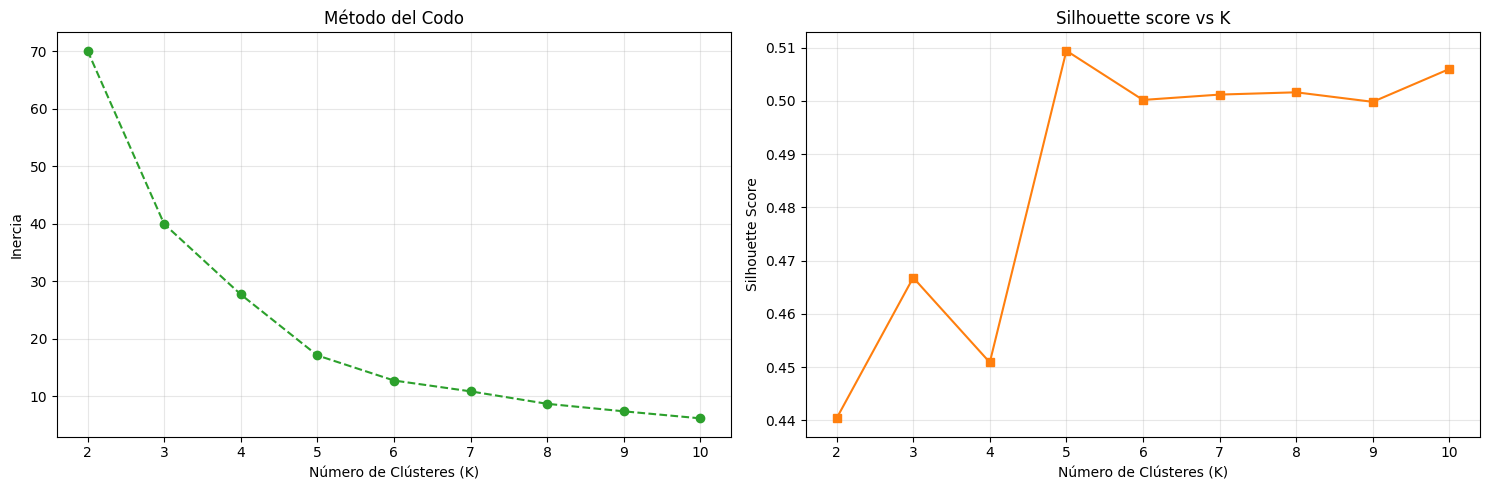

In [33]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Inicialización de contenedores vectoriales para el almacenamiento de métricas de desempeño
inercias_pca = []
siluetas_pca = []

# Definición del rango dinámico
rango_k = range(2, 11)

for k in rango_k:
    # Ajuste del estimador particional utilizando la matriz reducida 'X_pca'
    kmeans_pca = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters_pca = kmeans_pca.fit_predict(X_pca)

    # Extracción de la inercia
    inercias_pca.append(kmeans_pca.inertia_)

    # Cuantificación del coeficiente de silueta promediado
    siluetas_pca.append(silhouette_score(X_pca, clusters_pca))

# ---------------------------------------------------------
# GRAFICA DE RESULTADOS
# ---------------------------------------------------------

# Inicialización de la figura multieje (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Representación visual de la tasa de cambio de la inercia (Método del Codo / Elbow Method)
ax1.plot(rango_k, inercias_pca, marker='o', linestyle='--', color='#2ca02c')
ax1.set_title('Método del Codo')
ax1.set_xlabel('Número de Clústeres (K)')
ax1.set_ylabel('Inercia')
ax1.set_xticks(rango_k)
ax1.grid(True, alpha=0.3)

# Gráfico 2: Evaluación del perfil de silueta para la identificación del número óptimo de agrupaciones
ax2.plot(rango_k, siluetas_pca, marker='s', linestyle='-', color='#ff7f0e')
ax2.set_title('Silhouette score vs K')
ax2.set_xlabel('Número de Clústeres (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_xticks(rango_k)
ax2.grid(True, alpha=0.3)

# Optimización automática de los márgenes y distribución espacial de los gráficos
plt.tight_layout()
plt.show()

In [34]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from IPython.display import display

inercias_pca = []
siluetas_pca = []

rango_k = range(2, 11)

for k in rango_k:
    kmeans_pca = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters_pca = kmeans_pca.fit_predict(X_pca)
    inercias_pca.append(kmeans_pca.inertia_)
    siluetas_pca.append(silhouette_score(X_pca, clusters_pca))

# ---------------------------------------------------------
#                TABLA RESUMEN
# ---------------------------------------------------------

# Construcción de la matriz estructurada correlacionando hiperparámetros y scores de rendimiento
tabla_evaluacion_pca = pd.DataFrame({
    "Número de Clústeres (K)": rango_k,
    "Inercia (Método del Codo)": inercias_pca,
    "Silhouette Score": siluetas_pca
})

# Aplicación de precisión flotante estandarizada
tabla_evaluacion_pca['Inercia (Método del Codo)'] = tabla_evaluacion_pca['Inercia (Método del Codo)'].round(2)
tabla_evaluacion_pca['Silhouette Score'] = tabla_evaluacion_pca['Silhouette Score'].round(4)

# Despliegue de los resultados tabulados en la consola del entorno de ejecución
print('       ----------------------------------------------------')
print("          Tabla de evaluación de cantidad de clusters")
print('       ----------------------------------------------------\n')
display(tabla_evaluacion_pca)

       ----------------------------------------------------
          Tabla de evaluación de cantidad de clusters
       ----------------------------------------------------



,Número de Clústeres (K),Inercia (Método del Codo),Silhouette Score
0,2,70.08,0.4404
1,3,39.97,0.4668
2,4,27.73,0.4509
3,5,17.12,0.5094
4,6,12.76,0.5002
5,7,10.88,0.5012
6,8,8.71,0.5016
7,9,7.41,0.4998
8,10,6.18,0.5060


###Visualización de cluster con técnica de Análisis de Componentes Principales (PCA)

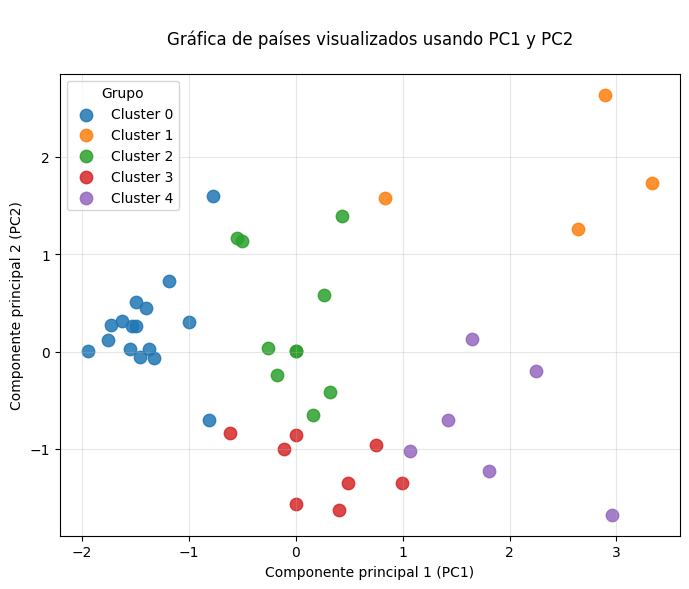

In [35]:
# Inicialización del lienzo gráfico
plt.figure(figsize=(8, 6))

# Segmentación y mapeo iterativo por subconjuntos discretos según la etiqueta de clúster única
for cluster in sorted(df_resultado['cluster'].unique()):
    # Aislamiento de observaciones pertenecientes al clúster evaluado en la iteración corriente
    datos_cluster = df_resultado[df_resultado['cluster'] == cluster]
    # Proyección ortogonal de las muestras utilizando las coordenadas del PC1 y PC2
    plt.scatter(
        datos_cluster['PC1'],
        datos_cluster['PC2'],
        label=f'Cluster {cluster}',
        s=80,
        alpha=0.85
    )

# Configuración de metadatos jerárquicos y descriptivos de los ejes coordenados
plt.title('\nGráfica de países visualizados usando PC1 y PC2\n')
plt.xlabel('Componente principal 1 (PC1)')
plt.ylabel('Componente principal 2 (PC2)')
plt.legend(title='Grupo')
plt.grid(True, alpha=0.3)
plt.show()

###Gráfica Representativa por Cluster

In [36]:
from IPython.display import display

# Configuración de variables de interes
variables_originales = ['BEEF', 'PIG', 'POULTRY', 'SHEEP']

#Perfil Promedio por Cluster
perfil_clusters = df_resultado.groupby('cluster')[variables_originales].mean().round(2)

print('-----------------------------------------------')
print(" CONSUMO PROMEDIO POR CLÚSTER (KG Per Cápita)")
print('-----------------------------------------------\n')
display(perfil_clusters)


# Análisis y distribución de elemnetos
print('\n-----------------------------------------------')
print("       CANTIDAD DE PAÍSES POR CLÚSTER")
print('-----------------------------------------------\n')
conteo_paises = df_resultado['cluster'].value_counts().sort_index()
print(conteo_paises)

-----------------------------------------------
 CONSUMO PROMEDIO POR CLÚSTER (KG Per Cápita)
-----------------------------------------------



SUBJECT,BEEF,PIG,POULTRY,SHEEP
cluster,,,,
0,2.88,1.39,3.37,1.36
1,26.10,12.68,22.31,10.49
2,7.42,4.26,22.55,2.52
3,9.13,18.46,11.90,0.70
4,25.03,12.52,36.20,0.87



-----------------------------------------------
       CANTIDAD DE PAÍSES POR CLÚSTER
-----------------------------------------------

cluster
0    16
1     4
2    10
3     8
4     6
Name: count, dtype: int64


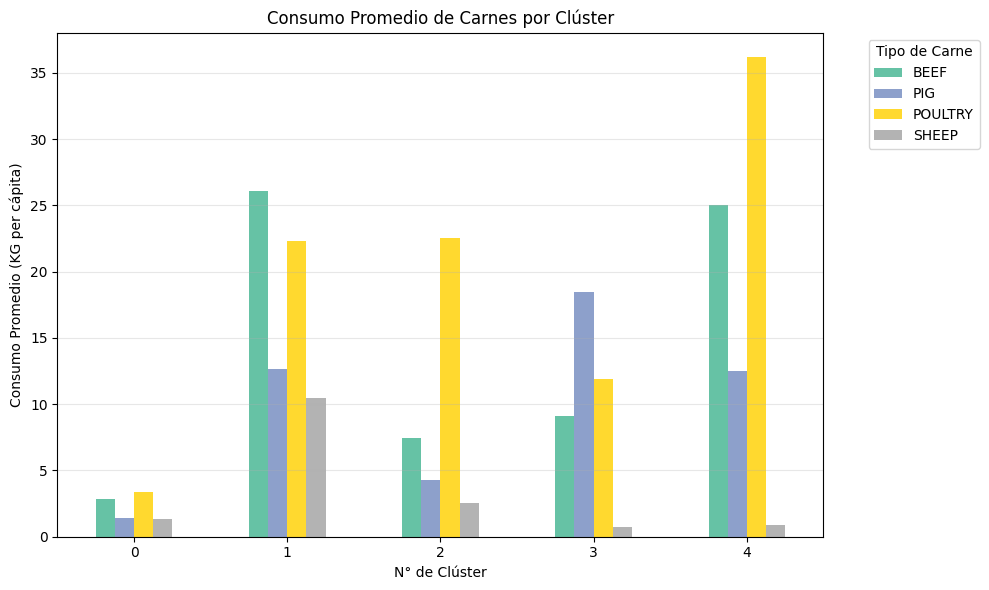

In [37]:
import matplotlib.pyplot as plt

# Especificación del conjunto de atributos cualitativos continuos para el contraste visual
variables_comparacion = ['BEEF', 'PIG', 'POULTRY', 'SHEEP']

# Renderizado del diagrama de barras agrupadas a partir de la matriz
perfil_clusters[variables_comparacion].plot(kind='bar', figsize=(10, 6), colormap='Set2')

# Definición de los metadatos y etiquetas del sistema de coordenadas cartesianas
plt.title('Consumo Promedio de Carnes por Clúster')
plt.xlabel('N° de Clúster')
plt.ylabel('Consumo Promedio (KG per cápita)')
plt.xticks(rotation=0)
plt.legend(title='Tipo de Carne', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

###Construcción del catálogo maestro para la interpretación de clústeres

In [38]:
interpretacion_carnes = pd.DataFrame({
    'cluster': [0, 1, 2, 3, 4],
    'perfil de consumidor': [
        'Consumidores mínimos',
        'Consumidores diversificados',
        'Consumidores moderados de pollo',
        'Consumidores porcinos',
        'Consumidores intensivos de pollo'
    ],
    'lectura': [
        'Consumo muy bajo en todas las carnes. Pollo lidera con solo 3.37 kg. '
        'Podrían ser países con bajo poder adquisitivo o dietas no carnívoras.',

        'Alto consumo en todas las carnes, especialmente vacuno (26.10 kg) y pollo (22.31 kg). '
        'Cordero también presente (10.49 kg). Perfil diversificado y de alto consumo.',

        'Consumo moderado liderado por pollo (22.55 kg). '
        'Vacuno y cerdo bajos. Perfil orientado a proteína blanca.',

        'Único clúster donde el cerdo (18.46 kg) supera al vacuno (9.13 kg). '
        'Pollo moderado (11.90 kg). Perfil con preferencia cultural por el cerdo.',

        'Mayor consumidor absoluto: pollo con 36.20 kg lidera ampliamente. '
        'Vacuno también alto (25.03 kg). Consumo total más alto de todos los clústeres.'
    ],
    'accion_posible': [
        'Estrategias de acceso y precio para estimular consumo básico.',
        'Ofertas premium y productos diferenciados para los 4 países del grupo.',
        'Potenciar productos avícolas y reducir precio de vacuno para diversificar.',
        'Reforzar oferta porcina con cortes especiales y productos procesados de cerdo.',
        'Aprovechar alta demanda avícola con variedades y presentaciones premium.'
    ]
})

print('                                               -------------------------')
print('                                                   Cátalogo de Cluster')
print('                                               -------------------------\n')

interpretacion_carnes

                                               -------------------------
                                                   Cátalogo de Cluster
                                               -------------------------



,cluster,perfil de consumidor,lectura,accion_posible
0,0,Consumidores mínimos,Consumo muy bajo en todas las carnes. Pollo li...,Estrategias de acceso y precio para estimular ...
1,1,Consumidores diversificados,"Alto consumo en todas las carnes, especialment...",Ofertas premium y productos diferenciados para...
2,2,Consumidores moderados de pollo,Consumo moderado liderado por pollo (22.55 kg)...,Potenciar productos avícolas y reducir precio ...
3,3,Consumidores porcinos,Único clúster donde el cerdo (18.46 kg) supera...,Reforzar oferta porcina con cortes especiales ...
4,4,Consumidores intensivos de pollo,Mayor consumidor absoluto: pollo con 36.20 kg ...,Aprovechar alta demanda avícola con variedades...


In [39]:
print('--------------------------------------------------')
print("        LISTADO DE ClUSTERS CON SUS PAÍSES  ")
print('--------------------------------------------------\n')

# Bucle secuencial ordenado para la segregación y mapeo de las agrupaciones del modelo
for cluster in sorted(df_resultado['cluster'].unique()):

    # Estratificación de las unidades de análisis regionales asociadas al clúster activo
    paises = df_resultado[df_resultado['cluster'] == cluster].index.tolist()

    # Despliegue del identificador del grupo y su tamaño
    print(f" CLÚSTER {cluster} ({len(paises)} países):\n")

    # Despliegue de reporte de paises que pertenecen al cluster
    print(", ".join(paises))
    print("-" * 60)
    print()

--------------------------------------------------
        LISTADO DE ClUSTERS CON SUS PAÍSES  
--------------------------------------------------

 CLÚSTER 0 (16 países):

BGD, DZA, EGY, ETH, GHA, HTI, IDN, IND, MOZ, NGA, PAK, SDN, SSA, THA, TZA, ZMB
------------------------------------------------------------

 CLÚSTER 1 (4 países):

AUS, KAZ, NZL, URY
------------------------------------------------------------

 CLÚSTER 2 (10 países):

CHE, COL, IRN, MEX, MYS, NOR, PER, SAU, TUR, ZAF
------------------------------------------------------------

 CLÚSTER 3 (8 países):

CHN, JPN, KOR, PHL, PRY, RUS, UKR, VNM
------------------------------------------------------------

 CLÚSTER 4 (6 países):

ARG, BRA, CAN, CHL, ISR, USA
------------------------------------------------------------



#### ANEXO : Modelo SIN Análisis de Componentes Principales (PCA)

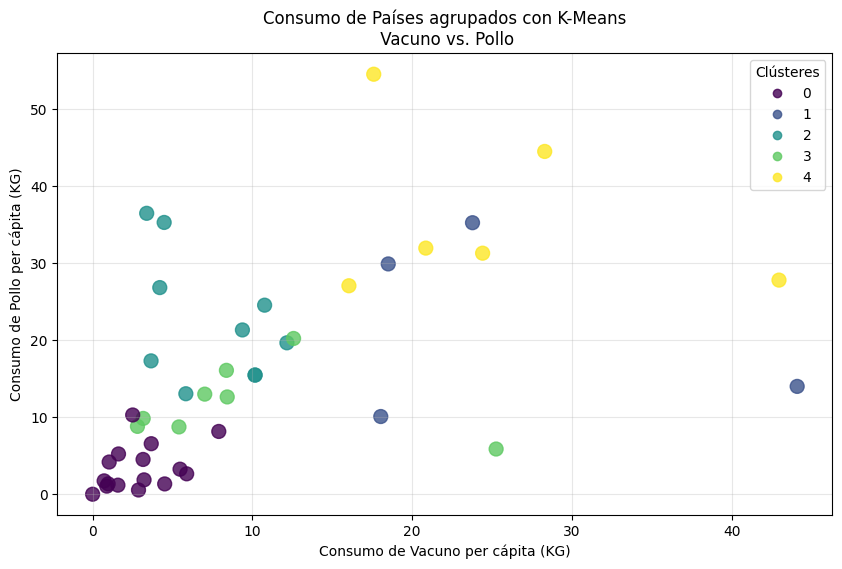

In [40]:
import matplotlib.pyplot as plt

# Inicialización del lienzo de visualización
plt.figure(figsize=(10, 6))

# Mapeo en el plano mediante un gráfico de dispersión
scatter = plt.scatter(
    df_resultado['BEEF'],
    df_resultado['POULTRY'],
    c=df_resultado['cluster'],
    cmap='viridis',  # Aplica una paleta secuencial perceptualmente uniforme y apta para daltónicos
    s=100,           # Tamaño del marcador (puntos)
    alpha=0.8        # Gestiona la superposición de datos
)

# Configuración y construción de los metadatos semánticos del gráfico
plt.title('Consumo de Países agrupados con K-Means\n Vacuno vs. Pollo')
plt.xlabel('Consumo de Vacuno per cápita (KG)')
plt.ylabel('Consumo de Pollo per cápita (KG)')
plt.legend(*scatter.legend_elements(), title="Clústeres") # Leyenda interactiva a partir de los cluster
plt.grid(True, alpha=0.3)
plt.show()

In [41]:
from sklearn.metrics import silhouette_score

# Extracción del indicador de dispersión geométrica interna (Inercia)
inertia = kmeans.inertia_

# Cálculo de la métrica de validación interna global (Coeficiente de Silueta)
silhouette = silhouette_score(X_escalado, clusters)

# Despliegue de reporte de resultados
print('-------------------------------------')
print("  Resultados de Evaluación para K=5 ")
print('-------------------------------------\n')
print("Inertia:", round(inertia, 2))
print("Silhouette Score:", round(silhouette, 4))
print()

-------------------------------------
  Resultados de Evaluación para K=5 
-------------------------------------

Inertia: 48.2
Silhouette Score: 0.3726



###Grafica del Método del codo

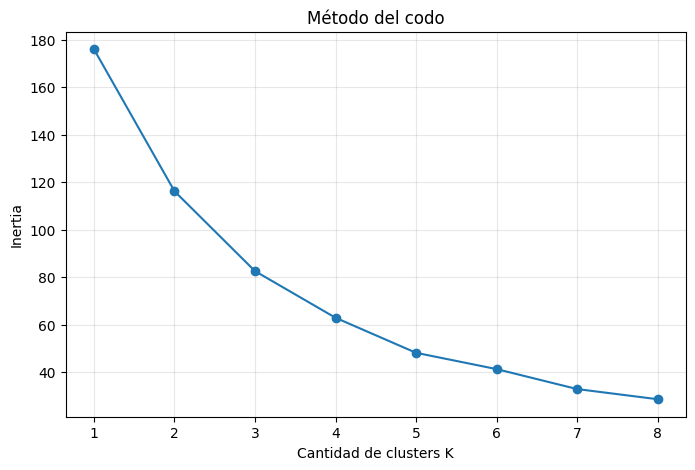

In [42]:
valores_k = []
inertias = []

for k in range(1, 9):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo.fit(X_escalado)
    valores_k.append(k)
    inertias.append(modelo.inertia_)

plt.figure(figsize=(8,5))
plt.plot(valores_k, inertias, marker='o')
plt.title('Método del codo')
plt.xlabel('Cantidad de clusters K')
plt.ylabel('Inertia')
plt.xticks(valores_k)
plt.grid(True, alpha=0.3)
plt.show()

###Grafica de indice Silhouette


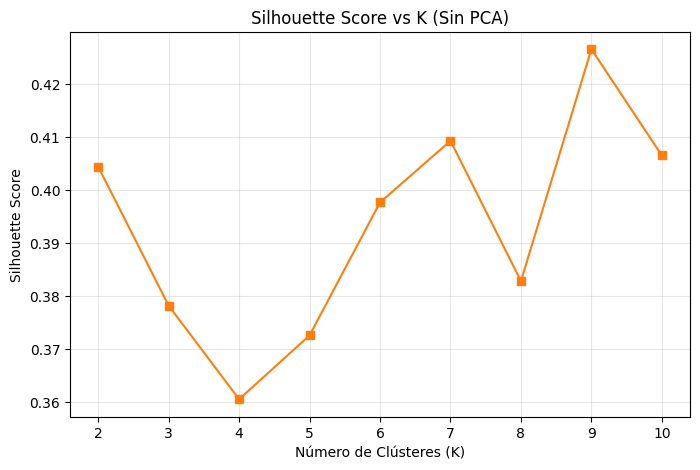

In [43]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


silhouette = []


rango_k = range(2, 11)

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_escalado)

    silhouette.append(silhouette_score(X_escalado, clusters))


plt.figure(figsize=(8, 5))

plt.plot(rango_k, silhouette, marker='s', linestyle='-', color='#ff7f0e')


plt.title('Silhouette Score vs K (Sin PCA)')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Silhouette Score')
plt.xticks(rango_k)
plt.grid(True, alpha=0.3)
plt.show()

## Evaluacion 3

In [6]:
import pandas as pd
import plotly.express as px

In [22]:
# Diccionario de tipos de carne
traduccion_carne = {
    "BEEF": "Carne bovina",
    "PIG": "Carne porcina",
    "POULTRY": "Carne de ave",
    "SHEEP": "Carne ovina"
}

# Crear columna traducida
df["Tipo de carne"] = df["SUBJECT"].map(traduccion_carne)

# Calcular consumo promedio
consumo_promedio = (
    df.groupby("Tipo de carne")["KG_CAP"]
      .mean()
      .reset_index()
      .sort_values("KG_CAP", ascending=False)
)

# Gráfico
fig_bar = px.bar(
    consumo_promedio,
    x="Tipo de carne",
    y="KG_CAP",
    color="Tipo de carne",
    title="Consumo promedio per cápita según tipo de carne",
    labels={
        "KG_CAP": "Consumo (kg per cápita)",
        "Tipo de carne": "Tipo de carne"
    }
)

fig_bar.update_layout(
    legend_title_text="Tipo de carne"
)

fig_bar.show()

In [23]:
# Crear columna en español
df["Tipo de carne"] = df["SUBJECT"].map(traduccion_carne)

# Agrupar usando la columna traducida
evolucion = (
    df.groupby(["TIME", "Tipo de carne"])["KG_CAP"]
      .mean()
      .reset_index()
)

fig_line = px.line(
    evolucion,
    x="TIME",
    y="KG_CAP",
    color="Tipo de carne",
    markers=True,
    title="Evolución temporal del consumo de carne por tipo",
    labels={
        "TIME": "Año",
        "KG_CAP": "Consumo (kg per cápita)",
        "Tipo de carne": "Tipo de carne"
    }
)

fig_line.update_layout(
    legend_title_text="Tipo de carne"
)

fig_line.show()

In [24]:
traduccion_paises = {
    "ARG": "Argentina",
    "AUS": "Australia",
    "BGD": "Bangladés",
    "BRA": "Brasil",
    "CAN": "Canadá",
    "CHE": "Suiza",
    "CHL": "Chile",
    "CHN": "China",
    "COL": "Colombia",
    "DZA": "Argelia",
    "EGY": "Egipto",
    "ETH": "Etiopía",
    "GHA": "Ghana",
    "HTI": "Haití",
    "IDN": "Indonesia",
    "IND": "India",
    "IRN": "Irán",
    "ISR": "Israel",
    "JPN": "Japón",
    "KAZ": "Kazajistán",
    "KOR": "Corea del Sur",
    "MEX": "México",
    "MOZ": "Mozambique",
    "MYS": "Malasia",
    "NGA": "Nigeria",
    "NOR": "Noruega",
    "NZL": "Nueva Zelanda",
    "PAK": "Pakistán",
    "PER": "Perú",
    "PHL": "Filipinas",
    "PRY": "Paraguay",
    "RUS": "Rusia",
    "SAU": "Arabia Saudita",
    "SDN": "Sudán",
    "SSA": "África Subsahariana",
    "THA": "Tailandia",
    "TUR": "Turquía",
    "TZA": "Tanzania",
    "UKR": "Ucrania",
    "URY": "Uruguay",
    "USA": "Estados Unidos",
    "VNM": "Vietnam",
    "ZAF": "Sudáfrica",
    "ZMB": "Zambia"
}

# Traducir países
df["Ubicación"] = df["LOCATION"].map(traduccion_paises)


df["Tipo de carne"] = df["SUBJECT"].map(traduccion_carne)

fig_scatter = px.scatter(
    df,
    x="TIME",
    y="KG_CAP",
    color="Tipo de carne",
    size="KG_CAP",
    hover_data=["Ubicación"],
    title="Distribución del consumo de carne por país y año",
    labels={
        "TIME": "Año",
        "KG_CAP": "Consumo (kg per cápita)",
        "Tipo de carne": "Tipo de carne",
        "Ubicación": "Ubicación"
    }
)

fig_scatter.show()

In [ ]:

ultimo_anio = df["TIME"].max()


df_map = df[
    (df["TIME"] == ultimo_anio) & 
    (df["Tipo de carne"] == "Carne bovina")
]


fig = px.choropleth(
    df_map,
    locations="LOCATION",
    locationmode="ISO-3",
    color="KG_CAP",
    hover_name="Ubicación",
    color_continuous_scale="Reds",
    title=f"Consumo per cápita de carne bovina en {ultimo_anio}",
    labels={"KG_CAP": "Consumo (kg per cápita)"}
)

fig.update_traces(
    hovertemplate=
    "<b>%{customdata[0]}</b><br>" +
    "Consumo: %{z:.2f} kg per cápita" +
    "<extra></extra>",
    customdata=df_map[["Ubicación"]]
)


fig.update_layout(
    width=1000, 
    height=600, 
    margin={"r": 0, "t": 50, "l": 0, "b": 0},
    geo=dict(
        showframe=False,
        showcoastlines=True
    )
)

fig.show()

In [27]:
df["Ubicación"] = df["LOCATION"].map(traduccion_paises)

top10 = (
    df[df["SUBJECT"] == "BEEF"]
    .groupby("Ubicación")["KG_CAP"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig = px.bar(
    top10,
    x="KG_CAP",
    y="Ubicación",
    orientation="h",
    color="KG_CAP",
    text="KG_CAP",
    title="Top 10 países con mayor consumo de carne bovina",
    labels={
        "KG_CAP": "Consumo per cápita (Kg)",
        "Ubicación": "Ubicación"
    }
)

# Formato de etiquetas y tooltip
fig.update_traces(
    texttemplate="%{x:.2f}",
    hovertemplate="<b>%{y}</b><br>Consumo: %{x:.2f} Kg per cápita<extra></extra>"
)

fig.show()

In [28]:
df["Tipo de carne"] = df["SUBJECT"].map(traduccion_carne)

fig = px.box(
    df,
    x="Tipo de carne",
    y="KG_CAP",
    color="Tipo de carne",
    points="outliers",
    title="Distribución del consumo per cápita según tipo de carne",
    labels={
        "KG_CAP": "Consumo per cápita (Kg)",
        "Tipo de carne": "Tipo de carne"
    }
)

fig.update_traces(
    hovertemplate=
    "<b>%{x}</b><br>" +
    "Consumo per cápita: %{y:.2f} Kg" +
    "<extra></extra>"
)

fig.show()

In [29]:
# Filtrar únicamente carne de ave
df_poultry = df[
    (df["SUBJECT"] == "POULTRY") &
    (df["KG_CAP"].notna())
]

fig = px.choropleth(
    df_poultry,
    locations="LOCATION",
    locationmode="ISO-3",   # Recomendado si LOCATION contiene códigos ISO-3
    color="KG_CAP",
    hover_name="Ubicación", # Si ya creaste esta columna traducida
    animation_frame="TIME",
    color_continuous_scale="Reds",
    range_color=(
        df_poultry["KG_CAP"].min(),
        df_poultry["KG_CAP"].max()
    ),
    title="Consumo per cápita de carne de ave por País y año",
    labels={
        "KG_CAP": "Consumo per cápita (Kg)"
    }
)

# Ocultar el código ISO del tooltip
fig.update_traces(
    hovertemplate=
    "<b>%{hovertext}</b><br>" +
    "Consumo: %{z:.2f} Kg per cápita" +
    "<extra></extra>"
)

fig.update_layout(
    height=700,
    margin=dict(l=0, r=0, t=60, b=0)
)

fig.show()